
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
df

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


1. Profundidades del pico en isla Torgersen:
   Máxima: 21.5 mm
   Mínima: 15.9 mm

2. Pingüino con mayor masa corporal:
   Isla: Biscoe
   Especie: Gentoo
   Género: Male
   Masa corporal: 6300.0 g

3. Masa corporal media de machos no Gentoo:
   4010.28 g



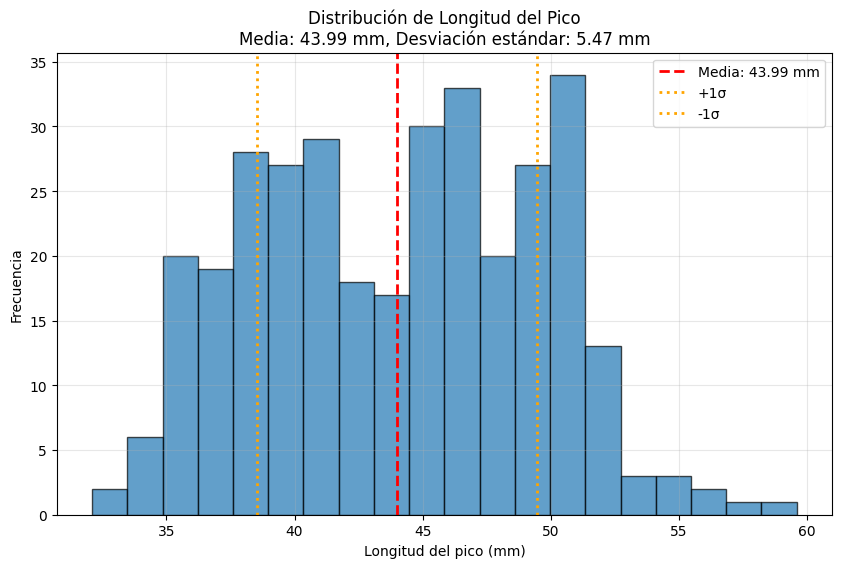


5a. Islas presentes:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

   Especies presentes:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


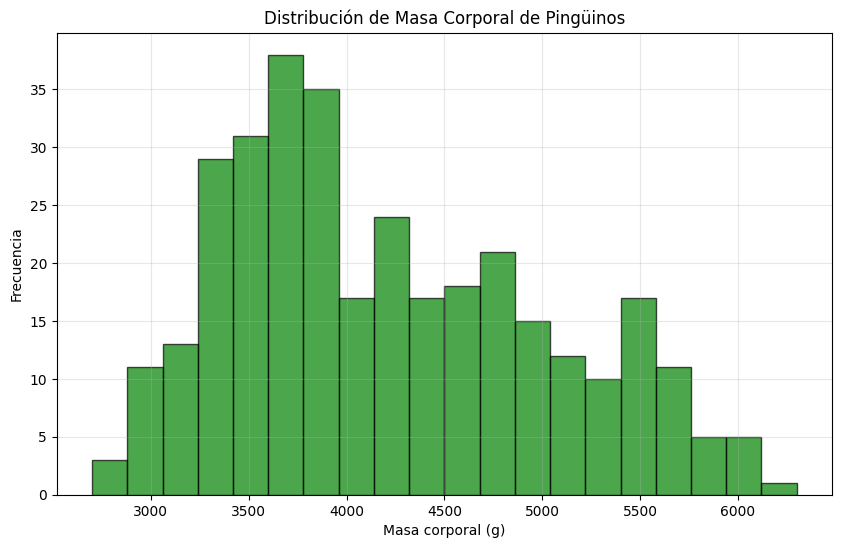

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
df = sns.load_dataset("penguins").dropna()
df.columns = ["especie", "isla", "longitud_pico (mm)",
              "profundidad_pico (mm)", "longitud_aleta (mm)",
              "masa_corporal (g)", "genero"]

# 1. Profundidades del pico máxima y mínima en isla Torgersen
torgersen = df[df['isla'] == 'Torgersen']
max_prof = torgersen['profundidad_pico (mm)'].max()
min_prof = torgersen['profundidad_pico (mm)'].min()
print("1. Profundidades del pico en isla Torgersen:")
print(f"   Máxima: {max_prof} mm")
print(f"   Mínima: {min_prof} mm\n")

# 2. Pingüino con mayor masa corporal
idx_max = df['masa_corporal (g)'].idxmax()
p_max = df.loc[idx_max]
print("2. Pingüino con mayor masa corporal:")
print(f"   Isla: {p_max['isla']}")
print(f"   Especie: {p_max['especie']}")
print(f"   Género: {p_max['genero']}")
print(f"   Masa corporal: {p_max['masa_corporal (g)']} g\n")

# 3. Masa corporal media de machos no Gentoo
filtro = (df['genero'] == 'Male') & (df['especie'] != 'Gentoo')
media_masa = df[filtro]['masa_corporal (g)'].mean()
print("3. Masa corporal media de machos no Gentoo:")
print(f"   {media_masa:.2f} g\n")

# 4. Gráfico de distribución de longitud del pico
plt.figure(figsize=(10, 6))
media = df['longitud_pico (mm)'].mean()
std = df['longitud_pico (mm)'].std()

plt.hist(df['longitud_pico (mm)'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f} mm')
plt.axvline(media + std, color='orange', linestyle='dotted', linewidth=2, label=f'+1σ')
plt.axvline(media - std, color='orange', linestyle='dotted', linewidth=2, label=f'-1σ')

plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Frecuencia')
plt.title(f'Distribución de Longitud del Pico\nMedia: {media:.2f} mm, Desviación estándar: {std:.2f} mm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5a. Islas y especies presentes con frecuencias
print("\n5a. Islas presentes:")
print(df['isla'].value_counts())
print("\n   Especies presentes:")
print(df['especie'].value_counts())

# 5b. Gráfico de distribución de masa corporal
plt.figure(figsize=(10, 6))
plt.hist(df['masa_corporal (g)'], bins=20, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Masa corporal (g)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Masa Corporal de Pingüinos')
plt.grid(True, alpha=0.3)
plt.show()

Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  

